# Problem 1 – CTG, kontynuacja Projektu 1

## Treść polecenia

W Projekcie 1 należało zilustrować w sposób obrazowy zbieżność rozkładu średniej do rozkładu normalnego 
zgodnie z Centralnym Twierdzeniem Granicznym (CTG) odpowiednimi wykresami. Tym razem chodzi o 
zastosowanie statystyki matematycznej i przeprowadzenie testów zgodności rozkładów. 

Tym razem proszę wybrać jeden tylko rozkład zmiennej X i zilustrować zbieżność rozkładu $\bar{X}_n$ (nie trzeba 
rozważać zbieżności średniej wybranej funkcji X jak to było w Projekcie 1). 

Do zbadania zgodności rozkładu $\bar{X}_n$ dla różnych n z rozkładem normalnym proszę wykorzystać: 
1. Test Kołmogorowa-Smirnowa 
2. Test Shapiro-Wilka 
3. Test D'Agostino

Wykorzystując symulacje komputerowe, proszę porównać moce powyższych testów dla ustalonego 
poziomu istotności i ocenić który test w analizowanym przypadku najskuteczniej wykrywa niezgodność z 
rozkładem normalnym. 

Dodatkowo, w ramach interpretacji działania testu D’Agostino proszę wyestymować wartości skośności i 
kurtozy. 

Proszę przyjąć umiarkowany rozmiar próby losowej „K” wynoszący kilkadziesiąt (tj. liczby obliczonych w 
pętli średnich, które będą podawane jako „wejście” dla testów – nie mylić z liczbą uśrednianych zmiennych 
losowych „n”). 


## Opis założeń

Stawiane hipotezy:
- $H_0$ - rozkład $\bar{X}_n$ jest normalny
- $H_1$ - rozkład $\bar{X}_n$ nie jest normalny

Do analizy wybrano silnie asymetryczny **rozkład wykładniczy** ($\lambda=1$).

Zdefiniowano następujące parametry symulacji:
* $n$ - liczba uśrednianych zmiennych losowych (zmienia się w celu pokazania działania CTG).
* $K$ - rozmiar próby podawanej do testu statystycznego ($K=50$).
* $M$ - liczba powtórzeń symulacji Monte Carlo do estymacji mocy testu ($M=5000$).
* $\alpha$ - poziom istotności testów ($\alpha=0.05$).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

np.random.seed(42)

# --- Simulation Parameters ---
SAMPLE_SIZES_N = [2, 3, 5, 8, 12, 20, 30, 50, 80, 120] 
TEST_SAMPLE_SIZE_K = 50 
N_SIMULATIONS_M = 5000 
ALPHA = 0.05

# Base Distribution: Exponential(lambda=1)
# True mean = 1.0, True variance = 1.0
TRUE_MEAN = 1.0
TRUE_VAR = 1.0

## 1. Główna pętla symulacyjna

Dla każdego rozmiaru $n$:
1. Generujemy $M$ razy próbę składającą się z $K$ średnich.
2. Każda średnia jest standaryzowana wzorem: $Z = \frac{\sqrt{n}(\overline{X}_n - \mu)}{\sigma}$.
3. Na ustandaryzowanej próbie wykonywane są trzy testy statystyczne. Jeśli `p-value < 0.05`, odrzucamy hipotezę $H_0$ o normalności.
4. Estymacja skośności i kurtozy (nadmiarowej) dla każdej próby.

In [9]:
# Dictionaries to store results
power_results = {
    'KS': [],
    'SW': [],
    'DA': []
}

moments_results = {
    'skewness': [],
    'kurtosis': []
}

print(f"Starting simulation for K={TEST_SAMPLE_SIZE_K}, M={N_SIMULATIONS_M} iterations...")

for n in tqdm(SAMPLE_SIZES_N, desc="Iterating over 'n'"):
    rejections_ks = 0
    rejections_sw = 0
    rejections_da = 0
    
    skews = []
    kurts = []
    
    for _ in range(N_SIMULATIONS_M):
        # 1. Generate K means, each calculated from n exponential variables
        raw_samples = stats.expon.rvs(scale=1.0, size=(TEST_SAMPLE_SIZE_K, n))
        sample_means = raw_samples.mean(axis=1)
        
        # 2. Standardize the means (crucial for KS test against N(0,1))
        z_scores = np.sqrt(n) * (sample_means - TRUE_MEAN) / np.sqrt(TRUE_VAR)
        
        # 3. Perform statistical tests
        # Kolmogorov-Smirnov
        if stats.kstest(z_scores, 'norm').pvalue < ALPHA:
            rejections_ks += 1
            
        # Shapiro-Wilk
        if stats.shapiro(z_scores).pvalue < ALPHA:
            rejections_sw += 1
            
        # D'Agostino's
        if stats.normaltest(z_scores).pvalue < ALPHA:
            rejections_da += 1
            
        # 4. Calculate skewness, kurtosis
        skews.append(stats.skew(z_scores))
        kurts.append(stats.kurtosis(z_scores))
        
    # Calculate power (proportion of rejections)
    power_results['KS'].append(rejections_ks / N_SIMULATIONS_M)
    power_results['SW'].append(rejections_sw / N_SIMULATIONS_M)
    power_results['DA'].append(rejections_da / N_SIMULATIONS_M)
    
    # Calculate average skewness, kurtosis for this 'n'
    moments_results['skewness'].append(np.mean(skews))
    moments_results['kurtosis'].append(np.mean(kurts))

print("Simulation completed!")

Starting simulation for K=50, M=5000 iterations...


Iterating over 'n': 100%|██████████| 10/10 [02:06<00:00, 12.69s/it]

Simulation completed!


## 2. Porównanie mocy testów statystycznych

W naszym przypadku, dla małych $n$, rozkład średnich jest asymetryczny (dziedziczy cechy rozkładu wykładniczego), więc testy powinny odrzucać $H_0$. Wraz ze wzrostem $n$, dzięki CTG, rozkład staje się normalny, a odsetek odrzuceń powinien spaść do poziomu błędu I rodzaju ($\alpha = 0.05$).

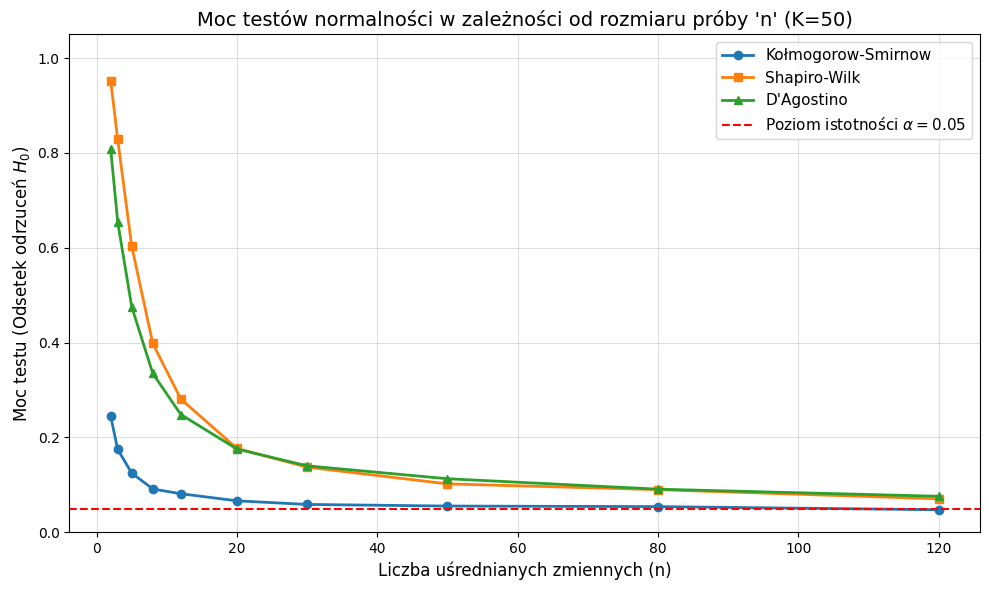

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(SAMPLE_SIZES_N, power_results['KS'], 'o-', label='Kołmogorow-Smirnow', lw=2)
plt.plot(SAMPLE_SIZES_N, power_results['SW'], 's-', label='Shapiro-Wilk', lw=2)
plt.plot(SAMPLE_SIZES_N, power_results['DA'], '^-', label="D'Agostino", lw=2)

# Add a horizontal line for the significance level alpha
plt.axhline(y=ALPHA, color='r', linestyle='--', label=r'Poziom istotności $\alpha=0.05$')

plt.title(f"Moc testów normalności w zależności od rozmiaru próby 'n' (K={TEST_SAMPLE_SIZE_K})", fontsize=14)
plt.xlabel("Liczba uśrednianych zmiennych (n)", fontsize=12)
plt.ylabel("Moc testu (Odsetek odrzuceń $H_0$)", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Interpretacja wykresu mocy testów

Na podstawie powyższego wykresu można wyciągnąć następujące wnioski:
1. **Zgodność z CTG:** Dla wszystkich trzech testów obserwujemy spadek mocy wraz ze wzrostem $n$. Oznacza to, że dla dużych $n$ testy przestają wykrywać różnice między rozkładem średnich a rozkładem normalnym, a odsetek odrzuceń stabilizuje się w okolicach poziomu istotności $\alpha = 0.05$.
2. **Skuteczność testów (Moc):** 
   * Najwyższą mocą charakteryzuje się test **Shapiro-Wilka** (pomarańczowa krzywa), który dla małych i średnich wartości $n$ (szczególnie w przedziale $n \in [2, 20]$) najskuteczniej wykrywa odstępstwa od normalności. Bardzo zbliżoną, choć minimalnie niższą skuteczność wykazuje test **D'Agostino** (zielona krzywa). Oba te testy są wysoce czułe na asymetrię rozkładu.
   * Zdecydowanie najsłabiej w tym zestawieniu wypada test **Kołmogorowa-Smirnowa** (niebieska krzywa). Jego moc jest drastycznie niższa już od samego początku (dla $n=2$ wynosi zaledwie ok. 0.25, podczas gdy SW jest nie daleko od 1.0). Oznacza to, że test KS jest bardzo mało czuły i najszybciej (błędnie) uznaje rozkład za normalny, ignorując asymetrię, która dla małych prób wciąż jest znacząca.

## 3. Analiza skośności i kurtozy (Interpretacja testu D'Agostino)

Test D'Agostino-Pearsona (K-kwadrat) opiera się na analizie momentów wyższych rzędów: skośności (miara asymetrii) oraz kurtozy (miara spłaszczenia/grubości ogonów). 
Dla idealnego rozkładu normalnego skośność wynosi 0, a kurtoza nadmiarowa (Fishera) również wynosi 0. Poniższy wykres ilustruje, jak te parametry zachowują się dla rozkładu średnich w miarę wzrostu $n$.

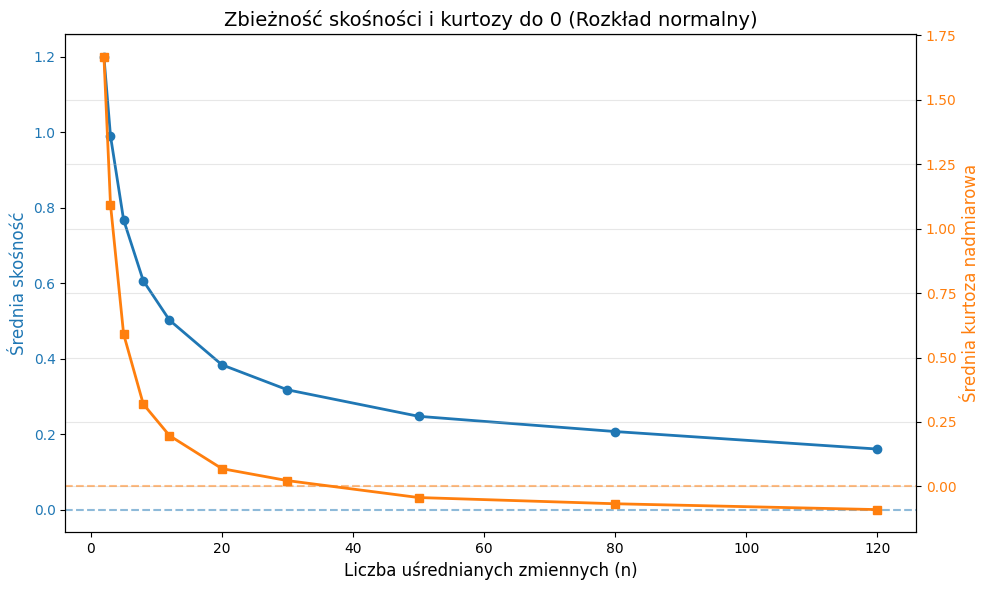

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Liczba uśrednianych zmiennych (n)', fontsize=12)
ax1.set_ylabel('Średnia skośność', color=color1, fontsize=12)
ax1.plot(SAMPLE_SIZES_N, moments_results['skewness'], 'o-', color=color1, lw=2, label='Skośność')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0, color=color1, linestyle='--', alpha=0.5)

ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis

color2 = 'tab:orange'
ax2.set_ylabel('Średnia kurtoza nadmiarowa', color=color2, fontsize=12)
ax2.plot(SAMPLE_SIZES_N, moments_results['kurtosis'], 's-', color=color2, lw=2, label='Kurtoza nadmiarowa')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(0, color=color2, linestyle='--', alpha=0.5)

plt.title("Zbieżność skośności i kurtozy do 0 (Rozkład normalny)", fontsize=14)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretacja wykresu momentów

1. **Skośność:** Rozkład bazowy (wykładniczy) charakteryzuje się silną prawostronną asymetrią (dodatnia skośność). Wykres pokazuje, że dla małych $n$ rozkład średnich dziedziczy tę asymetrię. Jednak zgodnie z CTG, w miarę wzrostu $n$, skośność (niebieska krzywa) systematycznie i asymptotycznie dąży do zera.
2. **Kurtoza:** Podobnie jak skośność, nadmiarowa kurtoza dla małych prób przyjmuje wartości dodatnie (rozkład bardziej "spiczasty" z grubszymi ogonami niż normalny). Wraz ze wzrostem $n$ wartość ta (pomarańczowa krzywa) spada bardzo gwałtownie, osiągając okolice zera znacznie szybciej niż skośność (już w okolicach $n=40-50$).
3. **Związek z testem D'Agostino:** 
   * Ponieważ test D'Agostino opiera się na badaniu statystycznej istotności odchyleń skośności i kurtozy od zera, wykres ten doskonale tłumaczy mechanizm działania i spadek mocy tego testu. Gdy wraz ze wzrostem $n$ oba te parametry zbliżają się do zera (wartości idealnych dla rozkładu normalnego), test D'Agostino traci matematyczne podstawy do odrzucenia hipotezy zerowej. Szybki spadek kurtozy i stopniowy spadek skośności idealnie korelują z kształtem zielonej krzywej mocy z pierwszego wykresu.